<a href="https://colab.research.google.com/github/dougyd92/ML-Foudations/blob/main/Notebooks/15_ConvNeuralNets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 15: Overfitting, CNNs, and Deep Learning Frameworks

This notebook covers three connected topics:
1. **Overfitting and regularization** in neural networks (dropout, early stopping)
2. **Convolutional Neural Networks** — from the convolution operation to building complete CNNs
3. **Deep learning frameworks** — building the same CNN in both PyTorch and Keras

We'll use Fashion-MNIST throughout: 28×28 grayscale images of clothing items (10 classes).

In [ ]:
# Setup: Run this cell first
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as klayers
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

# Matplotlib defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Device setup for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("All imports successful!")

PyTorch device: cuda
PyTorch version: 2.10.0+cu128
TensorFlow version: 2.19.0
All imports successful!


---
# Data: Fashion-MNIST

We'll load Fashion-MNIST once and prepare it for both PyTorch and Keras. This dataset has 60,000 training and 10,000 test images of 10 clothing categories, each 28×28 pixels in grayscale.

In [ ]:
# Load Fashion-MNIST via Keras (convenient loader, works for both frameworks)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

# Class names for labeling
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training set: {X_train_raw.shape}, Labels: {y_train_raw.shape}")
print(f"Test set:     {X_test_raw.shape}, Labels: {y_test_raw.shape}")
print(f"Pixel range:  {X_train_raw.min()} to {X_train_raw.max()}")
print(f"Classes:      {class_names}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28), Labels: (60000,)
Test set:     (10000, 28, 28), Labels: (10000,)
Pixel range:  0 to 255
Classes:      ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


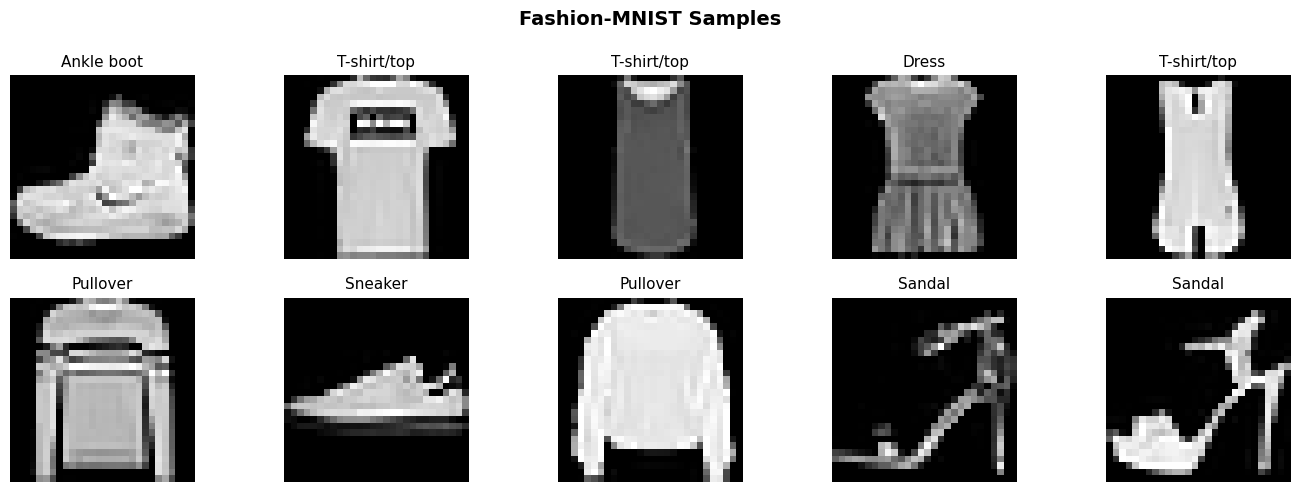

In [ ]:
# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(class_names[y_train_raw[i]], fontsize=11)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Normalize to [0, 1] and prepare for both frameworks
X_train_np = X_train_raw.astype('float32') / 255.0
X_test_np = X_test_raw.astype('float32') / 255.0


In [ ]:
X_test_raw[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  13,  67,   0,
          0,   0,   0,  50,  38,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   8, 120, 209, 226, 247, 237,
        255, 255, 255, 247, 238, 235, 172,  72,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 137, 239, 252, 243, 234, 229, 238,
        244, 246, 240, 230, 232, 239, 248, 251, 194,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 102, 255, 231, 228, 227, 228, 233, 230,
        230, 229, 228, 232, 232, 231, 227, 224, 252, 179,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 233, 241, 229, 231, 255, 255, 238, 231,
        227, 238, 246, 228, 230, 227, 234, 235, 229, 241,  20,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 248, 241, 231, 255, 149,  47, 252, 228,
        255, 242, 216, 238, 232, 255, 228, 220, 234, 250,  54,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 255, 240, 232, 255,  15,   0, 255, 237,
        191,   0,   0, 214, 255,  13, 123, 255, 234, 252, 114,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   6, 255, 238, 239, 255, 177,   0, 255, 255,
          0, 130, 116,  47,  65,  43,  37, 255, 236, 249, 162,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  32, 255, 236, 245, 255, 204,   0, 255,  84,
          0,  37,  28,  31,   0,  25,  13, 255, 236, 249, 199,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  53, 255, 236, 250, 250, 231,   2, 255,  21,
          0, 221, 255, 236,  54, 245, 198, 243, 238, 245, 223,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  80, 255, 237, 250, 240, 255,   0,   0,  39,
        157,   0,   0, 215,  94,  20, 126, 255, 237, 239, 250,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 101, 255, 235, 253, 244, 243, 133, 138, 208,
        255, 201, 214, 255, 230,   7, 174, 255, 240, 238, 255,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 126, 255, 233, 255, 248, 233, 255, 255, 240,
        232, 243, 243, 231, 251, 255, 255, 254, 243, 238, 255,   3,   0,
          0,   0],
       [  0,   0,   0,   0, 147, 255, 233, 249, 181, 243, 227, 224, 230,
        234, 230, 230, 235, 228, 235, 222, 207, 255, 236, 255,  35,   0,
          0,   0],
       [  0,   0,   0,   0, 163, 255, 245, 221,  86, 255, 233, 233, 235,
        236, 234, 234, 234, 232, 242, 231, 125, 255, 236, 255,  55,   0,
          0,   0],
       [  0,   0,   0,   0, 181, 254, 255, 200,  69, 255, 228, 232, 234,
        235, 234, 234, 233, 235, 241, 237,  70, 255, 235, 246,  57,   0,
          0,   0],
       [  0,   0,   0,   0, 197, 247, 255, 188, 110, 255, 224, 233, 234,
        234, 234, 234, 234, 234, 240, 253,  69, 255, 236, 248,  77,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 246, 255, 149, 145, 255, 223, 235, 234,
        235, 235, 235, 234, 237, 233, 255,  47, 255, 239, 249,  98,   0,
          0,   0],
       [  0,   0,   0,   0, 204, 243, 255, 111, 173, 255, 227, 235, 235,
        236, 235, 235, 235, 239, 229, 255,  19, 227, 246, 249, 110,   0,
          0,   0],
       [  0,   0,   0,   0, 196, 240, 255, 109, 213, 250, 229, 235, 235,
        236, 235, 237, 236, 237, 226, 255,  55, 203, 251, 245, 120,   0,
          0,   0],
       [  0,   0,   0,   0, 192, 243, 255, 114, 232, 240, 232, 235, 235,
        236, 234, 237, 236, 235, 229, 255, 134, 171, 252, 244, 137,   0,
          0,   0],
       [  0,   0,   0,   0, 189, 251, 255, 154, 238, 233, 236, 234, 235,
        236, 235, 238, 236, 235, 232, 255, 166, 125, 255, 243, 142,   0,
          0,   0],
       [  0,   0,   0,   0, 183, 252, 255, 171, 247, 232, 234, 234, 233,
        233, 232, 234, 233, 234, 233, 240, 223, 128, 255, 242, 151,   0,
          0,   0],
       [  0,   0,   0,   0, 178, 243, 255,  57, 238, 241, 238, 238, 238,
        237, 236, 237, 237, 240, 237, 254, 176,  52, 255, 239, 157,   0,
          0,   0],
       [  0,   0,   0,   0, 188, 240, 25

In [ ]:
X_test_np[1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.05098039, 0.2627451 , 0.        , 0.        , 0.        ,
        0.        , 0.19607843, 0.14901961, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.03137255, 0.47058824, 0.81960785,
        0.8862745 , 0.96862745, 0.92941177, 1.        , 1.        ,
        1.        , 0.96862745, 0.93333334, 0.92156863, 0.6745098 ,
        0.28235295, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.5372549 , 0.9372549 , 0.9882353 , 0.9529412 ,
        0.91764706, 0.8980392 , 0.93333334, 0.95686275, 0.9647059 ,
        0.9411765 , 0.9019

In [ ]:
# --- Keras format: (N, H, W, C) - channels last ---
X_train_keras = X_train_np[..., np.newaxis]  # (60000, 28, 28, 1)
X_test_keras = X_test_np[..., np.newaxis]

# --- PyTorch format: (N, C, H, W) - channels first ---
X_train_torch = torch.FloatTensor(X_train_np).unsqueeze(1)  # (60000, 1, 28, 28)
y_train_torch = torch.LongTensor(y_train_raw.copy())
X_test_torch = torch.FloatTensor(X_test_np).unsqueeze(1)
y_test_torch = torch.LongTensor(y_test_raw.copy())

# Split off a validation set from training data (last 10,000 samples)
X_val_torch = X_train_torch[-10000:]
y_val_torch = y_train_torch[-10000:]
X_train_torch_split = X_train_torch[:50000]
y_train_torch_split = y_train_torch[:50000]

# PyTorch DataLoaders
train_dataset = TensorDataset(X_train_torch_split, y_train_torch_split)
val_dataset = TensorDataset(X_val_torch, y_val_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)
test_loader = DataLoader(test_dataset, batch_size=256)

print(f"Keras shapes:  train {X_train_keras.shape}, test {X_test_keras.shape}")
print(f"PyTorch shapes: train {X_train_torch_split.shape}, val {X_val_torch.shape}, test {X_test_torch.shape}")
print(f"Pixel range after normalization: {X_train_np.min():.1f} to {X_train_np.max():.1f}")

Keras shapes:  train (60000, 28, 28, 1), test (10000, 28, 28, 1)
PyTorch shapes: train torch.Size([50000, 1, 28, 28]), val torch.Size([10000, 1, 28, 28]), test torch.Size([10000, 1, 28, 28])
Pixel range after normalization: 0.0 to 1.0


---
# Section 1: Overfitting and Regularization

Neural networks have enough parameters to memorize the training data. In this section, we'll see overfitting happen, then fix it with dropout and early stopping.

### A Training Helper Function

We'll reuse this function throughout the notebook to train PyTorch models and track loss curves.

In [ ]:
def train_pytorch_model(model, train_loader, val_loader, n_epochs=20, lr=0.001):
    """Train a PyTorch model and return loss history."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward() # Does backpropagation
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                val_total += y_batch.size(0)

        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(val_correct / val_total)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}: "
                  f"train_loss={history['train_loss'][-1]:.4f}, "
                  f"val_loss={history['val_loss'][-1]:.4f}, "
                  f"val_acc={history['val_acc'][-1]:.4f}")

    return history

### Demo: Overfitting a Dense Network

This model is deliberately oversized for Fashion-MNIST: wide hidden layers and no regularization. Watch the training loss keep dropping while validation loss climbs.

In [ ]:
# A dense network with no regularization — designed to overfit
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model_overfit = OverfitMLP()
total_params = sum(p.numel() for p in model_overfit.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Training samples: {len(train_dataset):,}")
print(f"Parameter-to-sample ratio: {total_params/len(train_dataset):.1f}x")

Model parameters: 535,818
Training samples: 50,000
Parameter-to-sample ratio: 10.7x


In [ ]:
# Train for 30 epochs — enough to see clear overfitting
print("Training without regularization...")
history_overfit = train_pytorch_model(model_overfit, train_loader, val_loader, n_epochs=30)

Training without regularization...
Epoch   5: train_loss=0.2835, val_loss=0.3244, val_acc=0.8844
Epoch  10: train_loss=0.2195, val_loss=0.3486, val_acc=0.8799
Epoch  15: train_loss=0.1776, val_loss=0.3473, val_acc=0.8904
Epoch  20: train_loss=0.1471, val_loss=0.3668, val_acc=0.8974
Epoch  25: train_loss=0.1240, val_loss=0.4209, val_acc=0.8955
Epoch  30: train_loss=0.1024, val_loss=0.4971, val_acc=0.8840


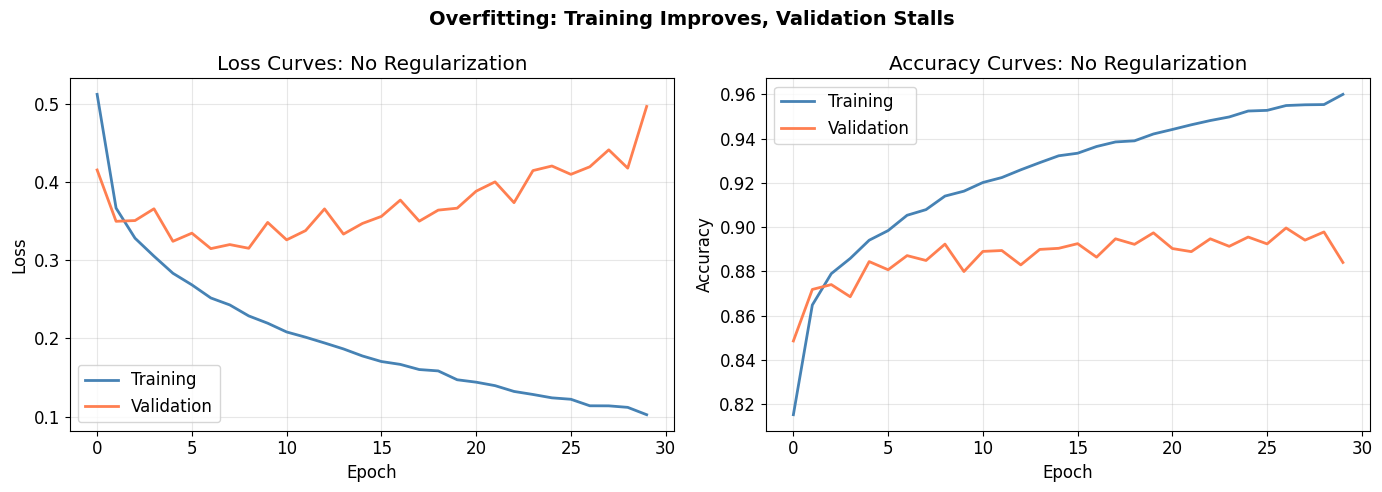

Final train accuracy: 0.9600
Final val accuracy:   0.8840
Generalization gap:   0.0760


In [ ]:
# Plot the diverging loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_overfit['train_loss'], label='Training', color='steelblue', linewidth=2)
ax1.plot(history_overfit['val_loss'], label='Validation', color='coral', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves: No Regularization')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_overfit['train_acc'], label='Training', color='steelblue', linewidth=2)
ax2.plot(history_overfit['val_acc'], label='Validation', color='coral', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves: No Regularization')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Overfitting: Training Improves, Validation Stalls', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

gap = history_overfit['train_acc'][-1] - history_overfit['val_acc'][-1]
print(f"Final train accuracy: {history_overfit['train_acc'][-1]:.4f}")
print(f"Final val accuracy:   {history_overfit['val_acc'][-1]:.4f}")
print(f"Generalization gap:   {gap:.4f}")

### Demo: Adding Dropout

Same architecture, but with dropout layers after each hidden layer. Dropout randomly deactivates neurons during training, forcing the network to build redundant representations.

In [ ]:
# Same architecture with dropout
class RegularizedMLP(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 512)
        self.drop1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, 256)
        self.drop2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.drop1(F.relu(self.fc1(x)))  # Dropout after activation
        x = self.drop2(F.relu(self.fc2(x)))
        return self.fc3(x)


model_dropout = RegularizedMLP(dropout_rate=0.3)
print("Training with dropout (p=0.3)...")
history_dropout = train_pytorch_model(model_dropout, train_loader, val_loader, n_epochs=30)

Training with dropout (p=0.3)...
Epoch   5: train_loss=0.3387, val_loss=0.3383, val_acc=0.8764
Epoch  10: train_loss=0.2933, val_loss=0.3112, val_acc=0.8872
Epoch  15: train_loss=0.2623, val_loss=0.3108, val_acc=0.8900
Epoch  20: train_loss=0.2430, val_loss=0.3044, val_acc=0.8939
Epoch  25: train_loss=0.2329, val_loss=0.3173, val_acc=0.8961
Epoch  30: train_loss=0.2157, val_loss=0.3059, val_acc=0.8998


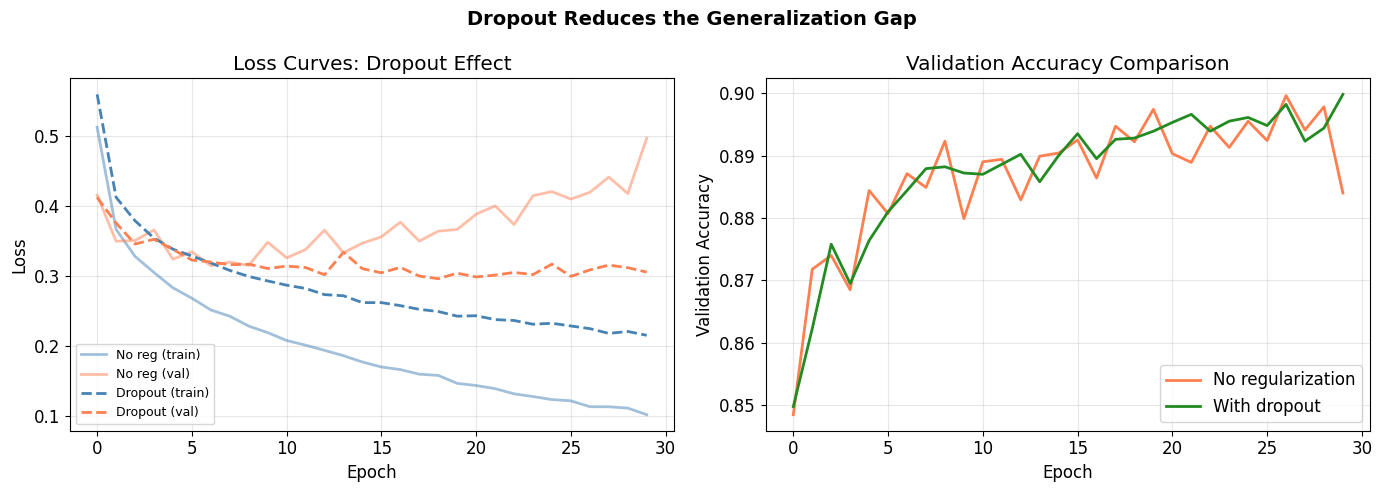

Generalization gap without dropout: 0.0760
Generalization gap with dropout:    0.0180


In [ ]:
# Compare: with vs. without dropout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_overfit['train_loss'], label='No reg (train)', color='steelblue', linewidth=2, alpha=0.5)
ax1.plot(history_overfit['val_loss'], label='No reg (val)', color='coral', linewidth=2, alpha=0.5)
ax1.plot(history_dropout['train_loss'], label='Dropout (train)', color='steelblue', linewidth=2, linestyle='--')
ax1.plot(history_dropout['val_loss'], label='Dropout (val)', color='coral', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves: Dropout Effect')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(history_overfit['val_acc'], label='No regularization', color='coral', linewidth=2)
ax2.plot(history_dropout['val_acc'], label='With dropout', color='forestgreen', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Dropout Reduces the Generalization Gap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

gap_overfit = history_overfit['train_acc'][-1] - history_overfit['val_acc'][-1]
gap_dropout = history_dropout['train_acc'][-1] - history_dropout['val_acc'][-1]
print(f"Generalization gap without dropout: {gap_overfit:.4f}")
print(f"Generalization gap with dropout:    {gap_dropout:.4f}")

### Demo: Early Stopping with Keras

Early stopping monitors validation loss and stops training when it stops improving. The `patience` parameter controls how many epochs to wait before stopping.

In [ ]:
# Build the same model in Keras to demonstrate early stopping
keras_mlp = keras.Sequential([
    klayers.Flatten(input_shape=(28, 28, 1)),
    klayers.Dense(512, activation='relu'),
    klayers.Dropout(0.3),
    klayers.Dense(256, activation='relu'),
    klayers.Dropout(0.3),
    klayers.Dense(10, activation='softmax')
])

keras_mlp.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,               # Wait 5 epochs for improvement
    restore_best_weights=True  # Go back to the best epoch
)

print("Training with early stopping (patience=5)...")
history_es = keras_mlp.fit(
    X_train_keras[:50000], y_train_raw[:50000],
    validation_data=(X_train_keras[50000:], y_train_raw[50000:]),
    epochs=50,  # Set high; early stopping will cut it short
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

stopped_epoch = len(history_es.history['loss'])
print(f"Training stopped at epoch {stopped_epoch} (max was 50)")
print(f"Best val accuracy: {max(history_es.history['val_accuracy']):.4f}")

Training with early stopping (patience=5)...
Training stopped at epoch 14 (max was 50)
Best val accuracy: 0.8838


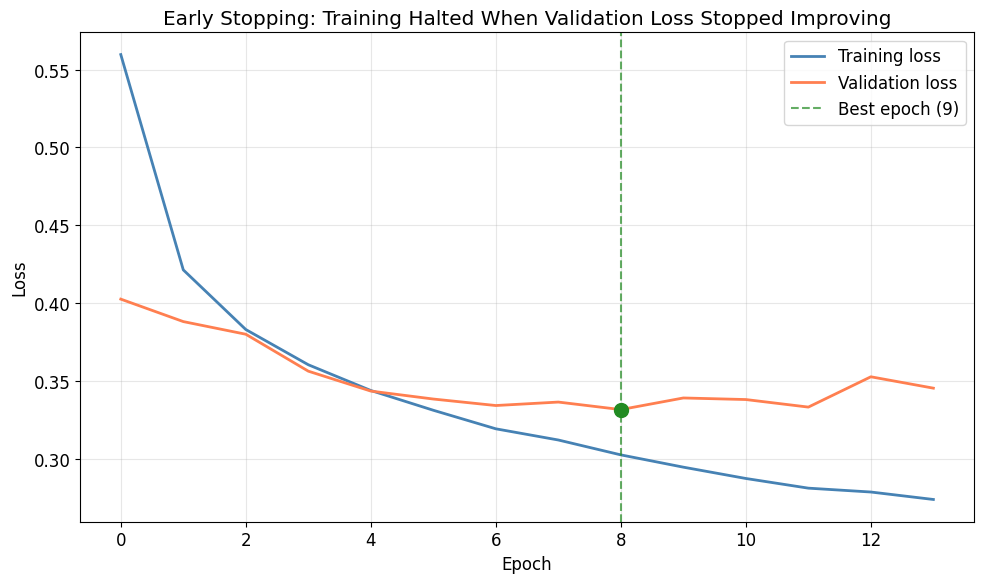

In [ ]:
# Plot early stopping behavior
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history_es.history['loss'], label='Training loss', color='steelblue', linewidth=2)
ax.plot(history_es.history['val_loss'], label='Validation loss', color='coral', linewidth=2)

# Mark the best epoch
best_epoch = np.argmin(history_es.history['val_loss'])
ax.axvline(x=best_epoch, color='forestgreen', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch+1})')
ax.scatter([best_epoch], [history_es.history['val_loss'][best_epoch]],
           color='forestgreen', s=100, zorder=5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Early Stopping: Training Halted When Validation Loss Stopped Improving')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Exercise 1: Diagnose and Fix Overfitting

A model is provided below that overfits on Fashion-MNIST. Your job: add regularization to improve its generalization.

### Task 1: Identify the Overfitting

Train the provided model and plot its loss curves. How large is the generalization gap?

In [ ]:
# This model has no regularization
class BigMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Train it and plot the loss curves
# Your code here

Epoch   5: train_loss=0.2845, val_loss=0.3169, val_acc=0.8850
Epoch  10: train_loss=0.2173, val_loss=0.3378, val_acc=0.8892
Epoch  15: train_loss=0.1728, val_loss=0.3204, val_acc=0.8955
Epoch  20: train_loss=0.1402, val_loss=0.4003, val_acc=0.8896
Epoch  25: train_loss=0.1181, val_loss=0.3919, val_acc=0.8965


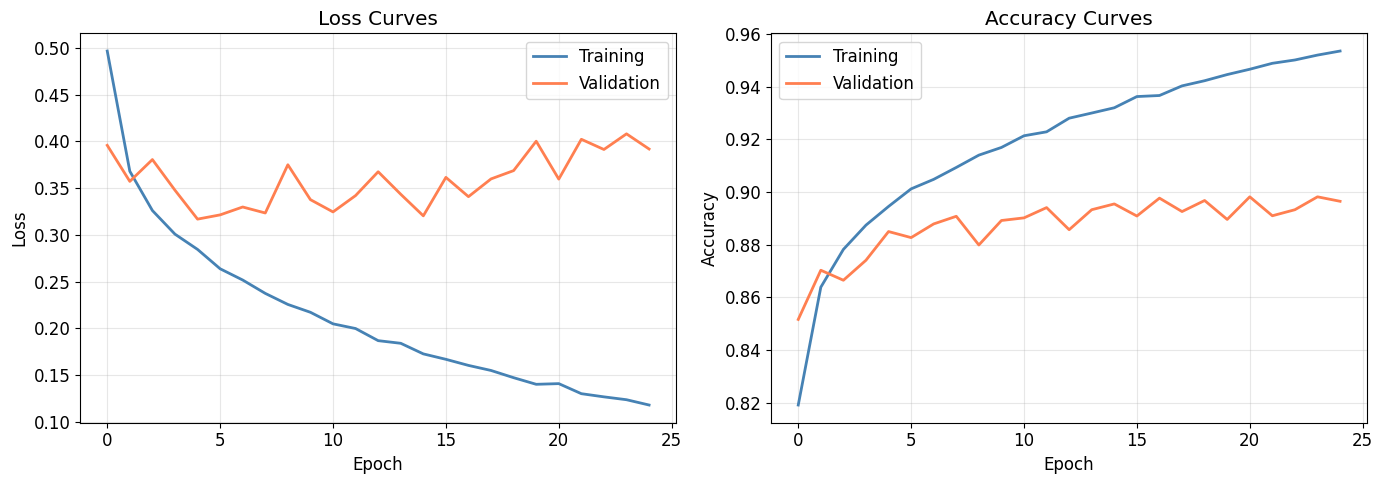

Generalization gap: 0.0571


In [ ]:
#@title Click to reveal solution

model_big = BigMLP()
history_big = train_pytorch_model(model_big, train_loader, val_loader, n_epochs=25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_big['train_loss'], label='Training', color='steelblue', linewidth=2)
ax1.plot(history_big['val_loss'], label='Validation', color='coral', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_big['train_acc'], label='Training', color='steelblue', linewidth=2)
ax2.plot(history_big['val_acc'], label='Validation', color='coral', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = history_big['train_acc'][-1] - history_big['val_acc'][-1]
print(f"Generalization gap: {gap:.4f}")

### Task 2: Add Dropout

Create a new version of `BigMLP` with dropout layers. Experiment with dropout rates between 0.2 and 0.5. Train and compare.

In [ ]:
# Create a regularized version of BigMLP with dropout
# Add nn.Dropout() layers after the ReLU activations

# Your code here

Epoch   5: train_loss=0.3593, val_loss=0.3382, val_acc=0.8768
Epoch  10: train_loss=0.3153, val_loss=0.3218, val_acc=0.8823
Epoch  15: train_loss=0.2932, val_loss=0.3194, val_acc=0.8829
Epoch  20: train_loss=0.2738, val_loss=0.3268, val_acc=0.8825
Epoch  25: train_loss=0.2611, val_loss=0.3054, val_acc=0.8911


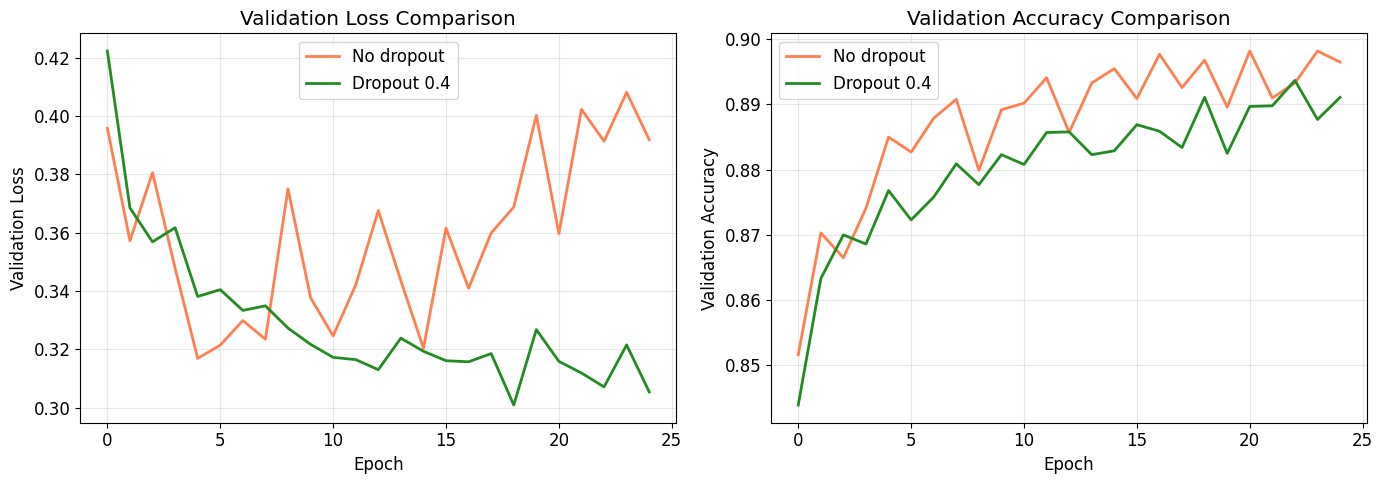

Generalization gap without dropout: 0.0571
Generalization gap with dropout:    0.0117


In [ ]:
#@title Click to reveal solution

class BigMLPDropout(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 1024)
        self.drop1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(1024, 512)
        self.drop2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.drop1(F.relu(self.fc1(x)))
        x = self.drop2(F.relu(self.fc2(x)))
        return self.fc3(x)

model_big_drop = BigMLPDropout(dropout_rate=0.4)
history_big_drop = train_pytorch_model(model_big_drop, train_loader, val_loader, n_epochs=25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_big['val_loss'], label='No dropout', color='coral', linewidth=2)
ax1.plot(history_big_drop['val_loss'], label='Dropout 0.4', color='forestgreen', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation Loss')
ax1.set_title('Validation Loss Comparison'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_big['val_acc'], label='No dropout', color='coral', linewidth=2)
ax2.plot(history_big_drop['val_acc'], label='Dropout 0.4', color='forestgreen', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy Comparison'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap_orig = history_big['train_acc'][-1] - history_big['val_acc'][-1]
gap_drop = history_big_drop['train_acc'][-1] - history_big_drop['val_acc'][-1]
print(f"Generalization gap without dropout: {gap_orig:.4f}")
print(f"Generalization gap with dropout:    {gap_drop:.4f}")

---
# Section 2: The Convolution Operation

Before using `nn.Conv2d` or `Conv2D`, let's implement convolution from scratch in NumPy. This is exactly the operation you did by hand on the worksheet.

### Demo: Manual Convolution in NumPy

We'll slide a 3×3 filter across an input image and compute the output feature map, one position at a time.

In [ ]:
def convolve2d(image, kernel):
    """Apply a 2D convolution (no padding, stride 1)."""
    h, w = image.shape
    kh, kw = kernel.shape
    out_h = h - kh + 1
    out_w = w - kw + 1
    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(patch * kernel)

    return output

# The same input and filter from the worksheet
input_grid = np.array([
    [1, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1]
], dtype=float)

vertical_edge_filter = np.array([
    [ 1, 0, -1],
    [ 1, 0, -1],
    [ 1, 0, -1]
], dtype=float)

output = convolve2d(input_grid, vertical_edge_filter)
print("Input (5x5):")
print(input_grid)
print(f"\nFilter (3x3): vertical edge detector")
print(vertical_edge_filter)
print(f"\nOutput (3x3):")
print(output)
print(f"\nPositive values = left edge, negative = right edge, zero = no edge")

Input (5x5):
[[1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]]

Filter (3x3): vertical edge detector
[[ 1.  0. -1.]
 [ 1.  0. -1.]
 [ 1.  0. -1.]]

Output (3x3):
[[ 3.  3.  0.]
 [ 2.  1. -1.]
 [ 1. -1. -2.]]

Positive values = left edge, negative = right edge, zero = no edge


### Demo: Edge Detection on a Real Image

Let's apply several classical filters to a Fashion-MNIST image and see what each one detects.

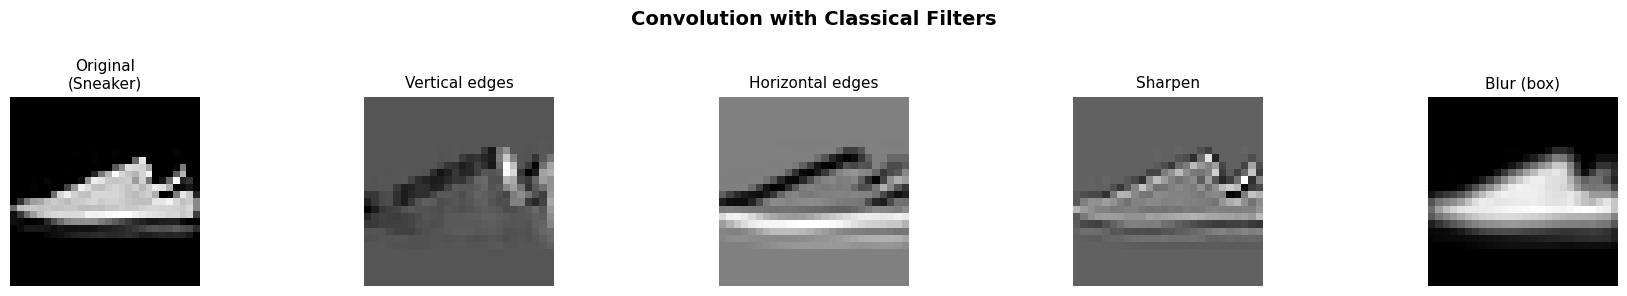

In [ ]:
# Define classical filters
filters = {
    'Vertical edges': np.array([[ 1, 0, -1], [ 1, 0, -1], [ 1, 0, -1]]),
    'Horizontal edges': np.array([[ 1, 1, 1], [ 0, 0, 0], [-1,-1,-1]]),
    'Sharpen': np.array([[ 0, -1, 0], [-1, 5, -1], [ 0, -1, 0]]),
    'Blur (box)': np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]]) / 9.0,
}

# Pick a sample image (a sneaker has clear edges)
sample_idx = 6  # Sneaker
sample_image = X_train_np[sample_idx]

fig, axes = plt.subplots(1, 5, figsize=(18, 3))

# Original
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title(f'Original\n({class_names[y_train_raw[sample_idx]]})', fontsize=11)
axes[0].axis('off')

# Apply each filter
for i, (name, kernel) in enumerate(filters.items()):
    filtered = convolve2d(sample_image, kernel)
    axes[i+1].imshow(filtered, cmap='gray')
    axes[i+1].set_title(name, fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('Convolution with Classical Filters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Demo: Weight Sharing Visualized

The same filter detects the same feature regardless of where it appears in the image. Let's verify: the vertical edge filter responds to vertical edges whether they're on the left or right side of the image.

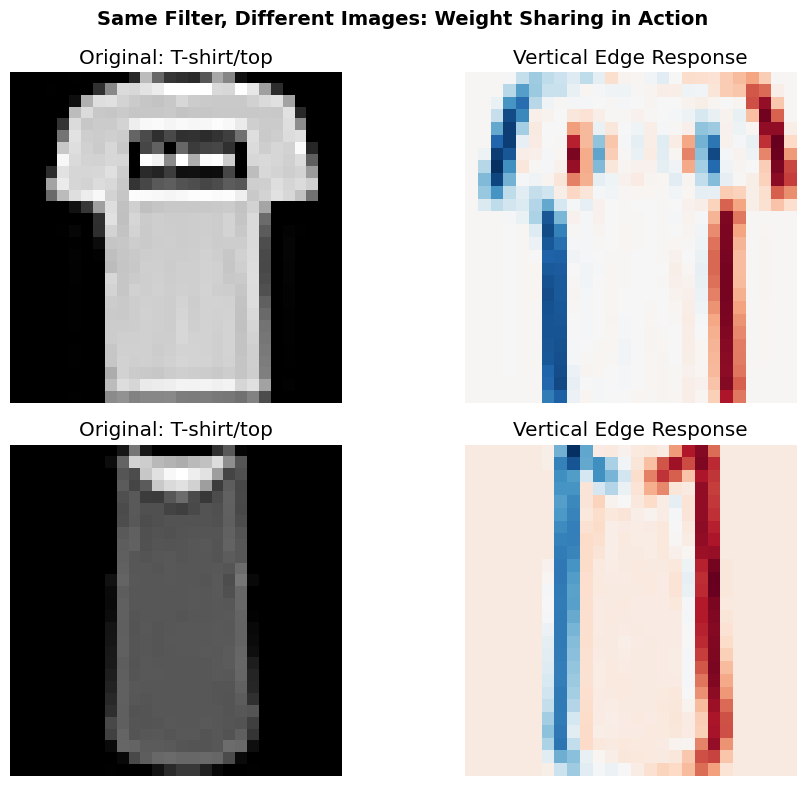

Same 9 parameters detect vertical edges everywhere in both images.


In [ ]:
# Show two different images with the same filter
idx1, idx2 = 1, 2  # T-shirt and Pullover — different shapes, same filter
img1, img2 = X_train_np[idx1], X_train_np[idx2]
v_edges_1 = convolve2d(img1, vertical_edge_filter)
v_edges_2 = convolve2d(img2, vertical_edge_filter)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].imshow(img1, cmap='gray')
axes[0,0].set_title(f'Original: {class_names[y_train_raw[idx1]]}'); axes[0,0].axis('off')
axes[0,1].imshow(v_edges_1, cmap='RdBu_r')
axes[0,1].set_title('Vertical Edge Response'); axes[0,1].axis('off')
axes[1,0].imshow(img2, cmap='gray')
axes[1,0].set_title(f'Original: {class_names[y_train_raw[idx2]]}'); axes[1,0].axis('off')
axes[1,1].imshow(v_edges_2, cmap='RdBu_r')
axes[1,1].set_title('Vertical Edge Response'); axes[1,1].axis('off')

plt.suptitle('Same Filter, Different Images: Weight Sharing in Action', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Same 9 parameters detect vertical edges everywhere in both images.")

---
## Exercise 2: Create and Apply Custom Filters

### Task 1: Design a Diagonal Edge Filter

Create a 3×3 filter that detects diagonal edges (top-left to bottom-right). Apply it to a Fashion-MNIST sample and display the result.

In [ ]:
# Hint: think about which positions should be positive vs. negative
# to detect a diagonal pattern

# diagonal_filter = np.array([...])
# result = convolve2d(sample_image, diagonal_filter)

# Your code here

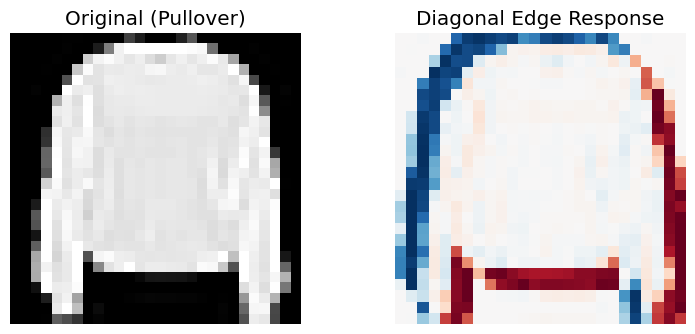

In [ ]:
#@title Click to reveal solution

diagonal_filter = np.array([
    [ 1,  0,  0],
    [ 0,  0,  0],
    [ 0,  0, -1]
], dtype=float)

result = convolve2d(sample_image, diagonal_filter)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
ax1.imshow(sample_image, cmap='gray')
ax1.set_title(f'Original ({class_names[y_train_raw[sample_idx]]})')
ax1.axis('off')
ax2.imshow(result, cmap='RdBu_r')
ax2.set_title('Diagonal Edge Response')
ax2.axis('off')
plt.tight_layout()
plt.show()

### Task 2: Verify the Output Size Formula

For each combination below, predict the output size using the formula: `output = (input - filter + 2*padding) / stride + 1`, then verify with a quick NumPy check.

In [ ]:
# Predict the output size for each case, then verify
# Case 1: input=28, filter=3, padding=0, stride=1
# Case 2: input=28, filter=5, padding=2, stride=1
# Case 3: input=28, filter=3, padding=0, stride=2

# Your predictions:
# Case 1: ___
# Case 2: ___
# Case 3: ___

# Verify with NumPy: create a random input and filter, apply convolve2d
# (convolve2d uses stride=1, no padding, so it checks Case 1 directly)

# Your code here

In [ ]:
#@title Click to reveal solution

# Case 1: (28 - 3 + 0) / 1 + 1 = 26
# Case 2: (28 - 5 + 4) / 1 + 1 = 28  (same padding preserves size)
# Case 3: (28 - 3 + 0) / 2 + 1 = 13  (stride 2 roughly halves)

# Verify Case 1 with NumPy
test_input = np.random.rand(28, 28)
test_filter = np.random.rand(3, 3)
test_output = convolve2d(test_input, test_filter)

print(f"Case 1: predicted 26x26, got {test_output.shape[0]}x{test_output.shape[1]}")
print(f"Case 2: predicted 28x28 (same padding not in our function, but formula gives 28)")
print(f"Case 3: predicted 13x13 (stride 2 not in our function, but formula gives 13)")

# Verify all three with PyTorch (which supports stride and padding)
x = torch.rand(1, 1, 28, 28)

conv1 = nn.Conv2d(1, 1, kernel_size=3, padding=0, stride=1, bias=False)
conv2 = nn.Conv2d(1, 1, kernel_size=5, padding=2, stride=1, bias=False)
conv3 = nn.Conv2d(1, 1, kernel_size=3, padding=0, stride=2, bias=False)

print(f"\nPyTorch verification:")
print(f"Case 1 (k=3, p=0, s=1): {conv1(x).shape[-1]}x{conv1(x).shape[-1]}")
print(f"Case 2 (k=5, p=2, s=1): {conv2(x).shape[-1]}x{conv2(x).shape[-1]}")
print(f"Case 3 (k=3, p=0, s=2): {conv3(x).shape[-1]}x{conv3(x).shape[-1]}")

Case 1: predicted 26x26, got 26x26
Case 2: predicted 28x28 (same padding not in our function, but formula gives 28)
Case 3: predicted 13x13 (stride 2 not in our function, but formula gives 13)

PyTorch verification:
Case 1 (k=3, p=0, s=1): 26x26
Case 2 (k=5, p=2, s=1): 28x28
Case 3 (k=3, p=0, s=2): 13x13


---
# Section 3: Building a CNN in PyTorch

Now we put the building blocks together: convolutional layers, pooling, flatten, and a dense classifier. This is the same architecture from Slide 39.

### Demo: CNN Architecture

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv block 1: 1 input channel -> 32 filters
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # Conv block 2: 32 -> 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Classifier
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.drop = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # (N,1,28,28) -> (N,32,14,14)

        # x = self.conv1(x)
        # x = self.bn1(x)
        # x = F.relu(x)
        # x = self.pool(x)   # (N,1,28,28) -> (N,32,14,14)


        # Block 2: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # (N,32,14,14) -> (N,64,7,7)
        # Classify
        x = self.flatten(x)                               # (N,64*7*7) = (N,3136)
        x = self.drop(F.relu(self.fc1(x)))                # (N,128)
        return self.fc2(x)                                 # (N,10)

model_cnn = FashionCNN()

# Print architecture and parameter count
print(model_cnn)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"\nTotal parameters: {total_params:,}")
print(f"Compare to dense MLP: {sum(p.numel() for p in OverfitMLP().parameters()):,}")

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,834
Compare to dense MLP: 535,818


### Demo: Training the CNN

In [ ]:
print("Training CNN on Fashion-MNIST...")
history_cnn = train_pytorch_model(model_cnn, train_loader, val_loader, n_epochs=15, lr=0.001)

Training CNN on Fashion-MNIST...
Epoch   5: train_loss=0.2134, val_loss=0.2336, val_acc=0.9140
Epoch  10: train_loss=0.1371, val_loss=0.2815, val_acc=0.9083
Epoch  15: train_loss=0.0924, val_loss=0.2664, val_acc=0.9199


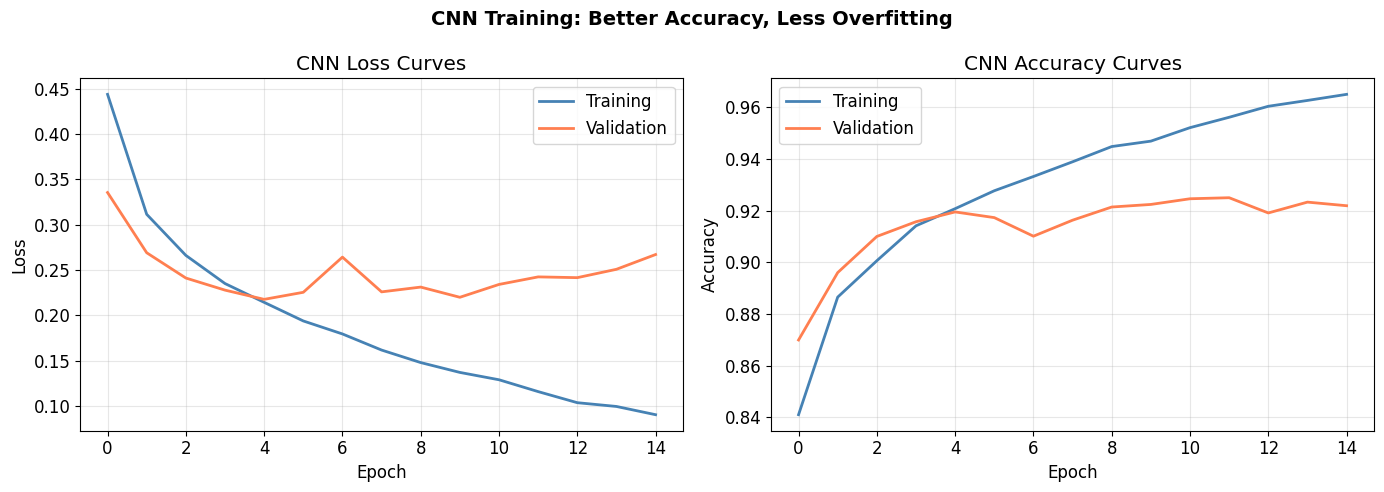

CNN val accuracy:  0.9219
Dense MLP val acc: 0.8947


In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn['train_loss'], label='Training', color='steelblue', linewidth=2)
ax1.plot(history_cnn['val_loss'], label='Validation', color='coral', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('CNN Loss Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_cnn['train_acc'], label='Training', color='steelblue', linewidth=2)
ax2.plot(history_cnn['val_acc'], label='Validation', color='coral', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('CNN Accuracy Curves'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Training: Better Accuracy, Less Overfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"CNN val accuracy:  {history_cnn['val_acc'][-1]:.4f}")
print(f"Dense MLP val acc: {history_overfit['val_acc'][-1]:.4f}")

### Demo: What Did the CNN Learn?

We can visualize the filters learned by the first convolutional layer. Unlike our hand-designed edge detectors, the network discovered these patterns on its own through backpropagation.

First conv layer filters shape: (32, 1, 3, 3)
  32 filters, each 3x3


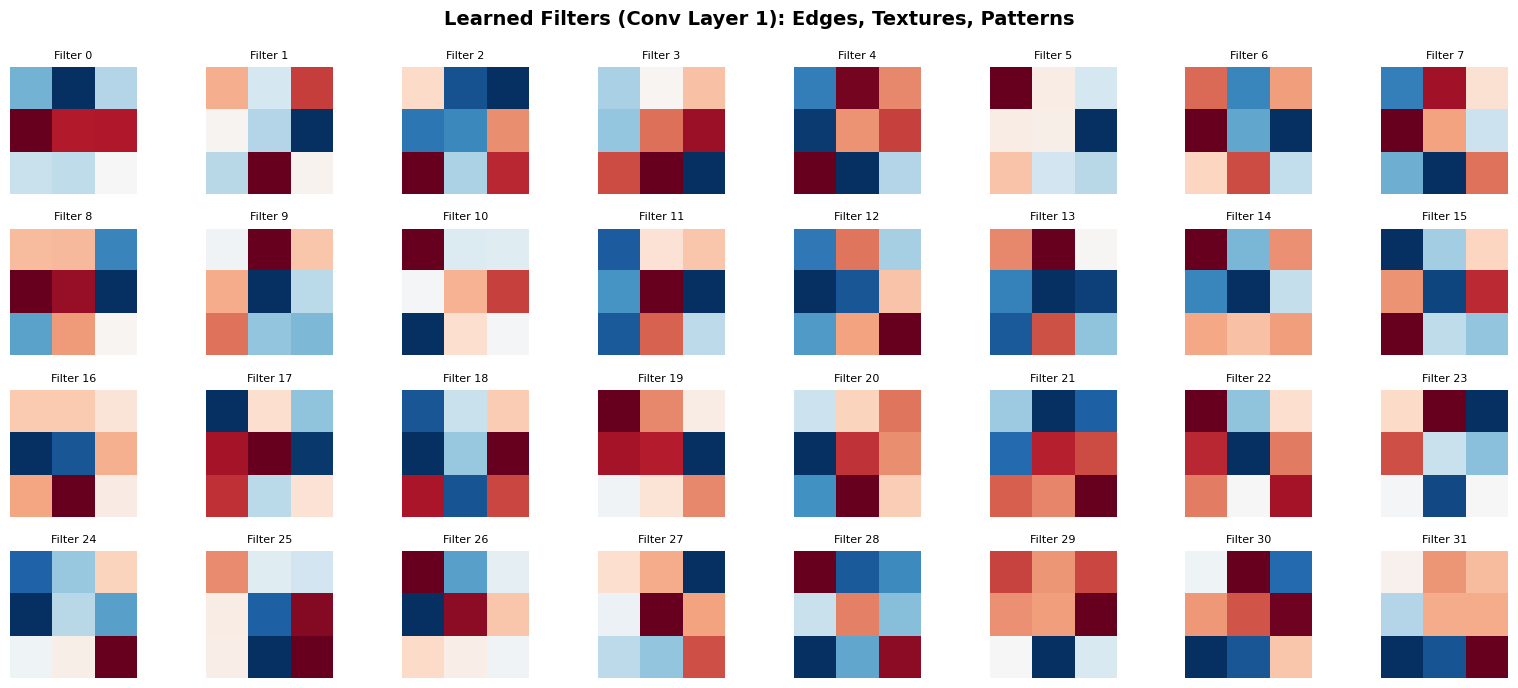

In [ ]:
# Visualize the first conv layer's learned filters
filters_learned = model_cnn.conv1.weight.data.cpu().numpy()
print(f"First conv layer filters shape: {filters_learned.shape}")
print(f"  {filters_learned.shape[0]} filters, each {filters_learned.shape[2]}x{filters_learned.shape[3]}")

fig, axes = plt.subplots(4, 8, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters_learned[i, 0], cmap='RdBu_r')
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Learned Filters (Conv Layer 1): Edges, Textures, Patterns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate on test set
model_cnn.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model_cnn(X_batch).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print("Test Set Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Set Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.90      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.88      0.88      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.90      0.85      0.87      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.78      0.73      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



---
## Exercise 3: Build Your Own CNN in PyTorch (Guided)

Fill in the missing pieces to build and train a CNN. The architecture is provided; you complete the layer definitions and forward pass.

### Task 1: Complete the CNN Definition

Fill in the missing layers. Target architecture:
- Conv block 1: Conv2d(1→16, 3×3, padding=1) → BatchNorm → ReLU → MaxPool(2×2)
- Conv block 2: Conv2d(16→32, 3×3, padding=1) → BatchNorm → ReLU → MaxPool(2×2)
- Classifier: Flatten → Linear(32×7×7, 64) → ReLU → Dropout(0.25) → Linear(64, 10)

In [ ]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv block 1: fill in Conv2d and BatchNorm2d
        self.conv1 = ___  # Conv2d: 1 input channel, 16 output, kernel 3, padding 1
        self.bn1 = ___    # BatchNorm2d for 16 channels
        self.pool = nn.MaxPool2d(2, 2)

        # Conv block 2: fill in Conv2d and BatchNorm2d
        self.conv2 = ___  # Conv2d: 16 input channels, 32 output, kernel 3, padding 1
        self.bn2 = ___    # BatchNorm2d for 32 channels

        # Classifier: fill in Linear layers and Dropout
        self.flatten = nn.Flatten()
        self.fc1 = ___    # Linear: 32*7*7 input, 64 output
        self.drop = ___   # Dropout with rate 0.25
        self.fc2 = ___    # Linear: 64 input, 10 output

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Classify
        x = self.flatten(x)
        x = self.drop(F.relu(self.fc1(x)))
        return self.fc2(x)

# Your code here (replace the ___ above)

In [ ]:
#@title Click to reveal solution

class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.drop(F.relu(self.fc1(x)))
        return self.fc2(x)

my_cnn = MyCNN()
print(my_cnn)
print(f"Total parameters: {sum(p.numel() for p in my_cnn.parameters()):,}")

MyCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Total parameters: 105,962


### Task 2: Train and Evaluate

Train your CNN for 10 epochs and report the test accuracy.

In [ ]:
# Train your model using the train_pytorch_model helper
# Then evaluate on the test set

# Your code here

In [ ]:
#@title Click to reveal solution

my_cnn = MyCNN()
print("Training MyCNN...")
history_my = train_pytorch_model(my_cnn, train_loader, val_loader, n_epochs=10)

# Test evaluation
my_cnn.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = my_cnn(X_batch).argmax(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print(f"\nTest accuracy: {correct/total:.4f}")

Training MyCNN...
Epoch   5: train_loss=0.2505, val_loss=0.2896, val_acc=0.8934
Epoch  10: train_loss=0.1892, val_loss=0.2412, val_acc=0.9146

Test accuracy: 0.9108


---
# Section 4: Building a CNN in Keras

The same CNN architecture, now in Keras. Notice how the `Sequential` API handles the forward pass implicitly and `.fit()` handles the entire training loop.

### Demo: CNN in Keras

In [ ]:
keras_cnn = keras.Sequential([
    # Conv block 1
    klayers.Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
    klayers.BatchNormalization(),
    klayers.Activation('relu'),
    klayers.MaxPooling2D((2, 2)),

    # Conv block 2
    klayers.Conv2D(64, (3, 3), padding='same'),
    klayers.BatchNormalization(),
    klayers.Activation('relu'),
    klayers.MaxPooling2D((2, 2)),

    # Classifier
    klayers.Flatten(),
    klayers.Dense(128, activation='relu'),
    klayers.Dropout(0.3),
    klayers.Dense(10, activation='softmax')
])

keras_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

keras_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Train with validation split and early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print("Training Keras CNN...")
keras_history = keras_cnn.fit(
    X_train_keras[:50000], y_train_raw[:50000],
    validation_data=(X_train_keras[50000:], y_train_raw[50000:]),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Training Keras CNN...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8206 - loss: 0.5031 - val_accuracy: 0.8484 - val_loss: 0.3941
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8753 - loss: 0.3439 - val_accuracy: 0.8689 - val_loss: 0.3302
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8916 - loss: 0.2961 - val_accuracy: 0.8951 - val_loss: 0.2916
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9032 - loss: 0.2668 - val_accuracy: 0.9030 - val_loss: 0.2731
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9109 - loss: 0.2428 - val_accuracy: 0.9060 - val_loss: 0.2615
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9168 - loss: 0.2258 - val_accuracy: 0.9151 - val_loss: 0.2431
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9227 - loss: 0.2071 - val_accuracy: 0.9158 - val_loss: 0.2404
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9280 - loss: 0.

In [ ]:
# Evaluate on test set
test_loss, test_acc = keras_cnn.evaluate(X_test_keras, y_test_raw, verbose=0)
print(f"Keras CNN test accuracy: {test_acc:.4f}")

Keras CNN test accuracy: 0.9112


### Demo: Comparing PyTorch and Keras Side by Side

Same architecture, same data, two frameworks. Let's compare the training curves.

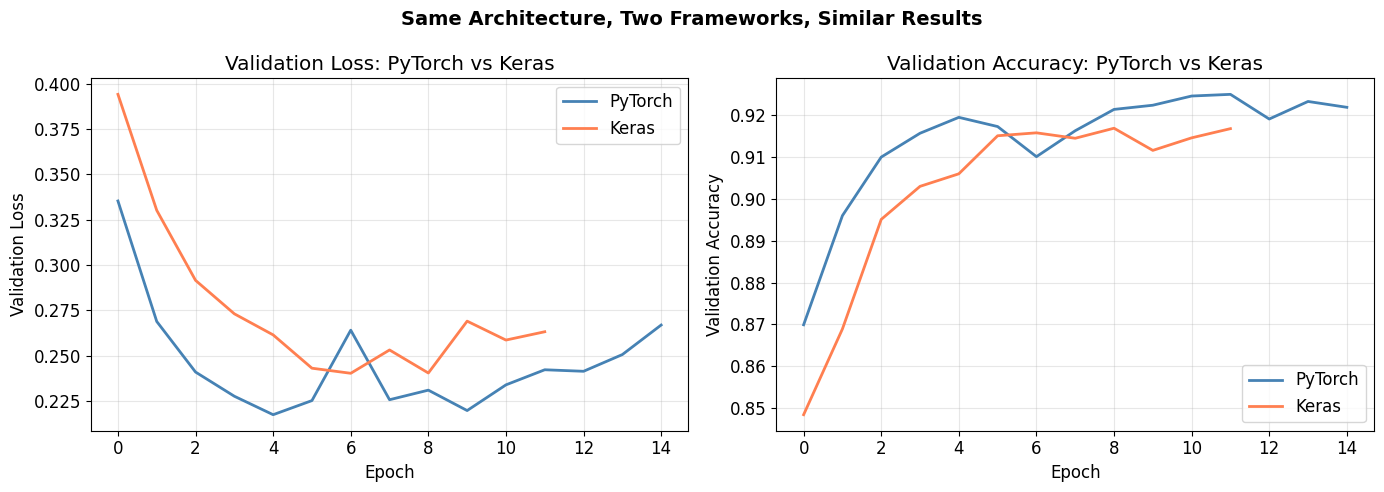

PyTorch CNN val accuracy: 0.9219
Keras CNN val accuracy:   0.9168


In [ ]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PyTorch curves
ax1.plot(history_cnn['val_loss'], label='PyTorch', color='steelblue', linewidth=2)
ax1.plot(keras_history.history['val_loss'], label='Keras', color='coral', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation Loss')
ax1.set_title('Validation Loss: PyTorch vs Keras')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_cnn['val_acc'], label='PyTorch', color='steelblue', linewidth=2)
ax2.plot(keras_history.history['val_accuracy'], label='Keras', color='coral', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validation Accuracy: PyTorch vs Keras')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Same Architecture, Two Frameworks, Similar Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"PyTorch CNN val accuracy: {history_cnn['val_acc'][-1]:.4f}")
print(f"Keras CNN val accuracy:   {keras_history.history['val_accuracy'][-1]:.4f}")

---
## Exercise 4: Build a Keras CNN with Regularization (Guided)

Build a CNN in Keras with both dropout and early stopping. This mirrors what you'd do in a real project: combine multiple regularization techniques.

### Task 1: Complete the Keras Model

Fill in the missing layers. Target architecture:
- Conv2D(16, 3×3, same padding, relu) → MaxPooling2D(2×2)
- Conv2D(32, 3×3, same padding, relu) → MaxPooling2D(2×2)
- Flatten → Dense(64, relu) → Dropout(0.4) → Dense(10, softmax)

In [ ]:
my_keras_cnn = keras.Sequential([
    # Conv block 1: fill in Conv2D and MaxPooling2D
    ___,  # Conv2D: 16 filters, 3x3, same padding, relu, input_shape=(28,28,1)
    ___,  # MaxPooling2D: 2x2

    # Conv block 2: fill in Conv2D and MaxPooling2D
    ___,  # Conv2D: 32 filters, 3x3, same padding, relu
    ___,  # MaxPooling2D: 2x2

    # Classifier: fill in Flatten, Dense, Dropout, Dense
    ___,  # Flatten
    ___,  # Dense: 64 units, relu
    ___,  # Dropout: 0.4
    ___,  # Dense: 10 units, softmax (output layer)
])

# Your code here (replace the ___ above)

ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received:  (of type <class 'str'>)

In [ ]:
#@title Click to reveal solution

my_keras_cnn = keras.Sequential([
    klayers.Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
    klayers.MaxPooling2D((2, 2)),

    klayers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    klayers.MaxPooling2D((2, 2)),

    klayers.Flatten(),
    klayers.Dense(64, activation='relu'),
    klayers.Dropout(0.4),
    klayers.Dense(10, activation='softmax')
])

my_keras_cnn.summary()

### Task 2: Compile, Train with Early Stopping, and Evaluate

Compile the model with Adam optimizer and sparse categorical crossentropy. Train with early stopping (patience=5). Report test accuracy.

In [ ]:
# 1. Compile the model
# 2. Create an EarlyStopping callback (patience=5, restore_best_weights=True)
# 3. Train on X_train_keras[:50000] with validation on X_train_keras[50000:]
# 4. Evaluate on X_test_keras

# Your code here

In [ ]:
#@title Click to reveal solution

my_keras_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

print("Training with early stopping...")
my_history = my_keras_cnn.fit(
    X_train_keras[:50000], y_train_raw[:50000],
    validation_data=(X_train_keras[50000:], y_train_raw[50000:]),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = my_keras_cnn.evaluate(X_test_keras, y_test_raw, verbose=0)
stopped_at = len(my_history.history['loss'])
print(f"\nStopped at epoch {stopped_at}")
print(f"Test accuracy: {test_acc:.4f}")

### Task 3: Plot Training Curves

Plot the training and validation loss curves. Mark the best epoch (lowest validation loss).

In [ ]:
# Plot loss curves and mark the best epoch
# Hint: best_epoch = np.argmin(my_history.history['val_loss'])

# Your code here

In [ ]:
#@title Click to reveal solution

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(my_history.history['loss'], label='Training', color='steelblue', linewidth=2)
ax1.plot(my_history.history['val_loss'], label='Validation', color='coral', linewidth=2)
best_epoch = np.argmin(my_history.history['val_loss'])
ax1.axvline(x=best_epoch, color='forestgreen', linestyle='--', alpha=0.7,
            label=f'Best epoch ({best_epoch+1})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves with Early Stopping')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(my_history.history['accuracy'], label='Training', color='steelblue', linewidth=2)
ax2.plot(my_history.history['val_accuracy'], label='Validation', color='coral', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Your CNN: Training with Dropout + Early Stopping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best validation loss at epoch {best_epoch+1}: {my_history.history['val_loss'][best_epoch]:.4f}")

---
# Summary

**Overfitting and Regularization**
- Neural networks easily memorize training data when they have more parameters than data points
- Dropout randomly deactivates neurons during training, forcing redundant representations
- Early stopping monitors validation loss and halts training before overfitting gets worse
- These techniques stack: use dropout + early stopping + batch norm together

**The Convolution Operation**
- A filter slides across the image, computing element-wise multiply-and-sum at each position
- Weight sharing: the same filter parameters are reused at every spatial location (9 parameters vs. millions)
- Stacking convolutional layers builds a hierarchy: edges → textures → parts → objects

**Building CNNs**
- The CNN pattern: Conv → BatchNorm → ReLU → Pool, repeated, then Flatten → Dense
- Spatial dimensions shrink (via pooling/stride) while channel count grows (via more filters)
- PyTorch: explicit `nn.Module` class + manual training loop gives full control
- Keras: `Sequential` API + `.compile()` + `.fit()` handles the loop for you
- Same math, same results, different levels of abstraction

**Next Session: Transfer Learning and Practical Deep Learning**
- Pre-trained models: use networks trained on ImageNet instead of starting from scratch
- Fine-tuning vs. feature extraction
- Data augmentation, learning rate schedules, and debugging training

**Project 4** (handwriting classification): you now have all the tools to build, train, and regularize a CNN.